# 01 — Data Validation and Exploratory Analysis

**Project:** Probabilistic, Adaptive, and Interpretable Prediction of Primary Crusher Energy Demand from Blast-Design Data in a Peruvian Open-Pit Copper Mine

This notebook reads the existing CSV from `../data/processed/blast_crusher.csv`. It does **not** generate records.

It performs:

- schema validation;
- data-quality checks;
- temporal inventory;
- target-variable summaries;
- exploratory graphics;
- correlation analysis;
- export of data-quality evidence.

> **Integrity note:** the notebook reports the contents of the CSV exactly as supplied, including the `data_status` field. Do not relabel the records without documentary evidence supporting the change.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
def locate_project_file(relative_path: str) -> Path:
    candidates = [
        Path(relative_path),
        Path.cwd() / relative_path,
        Path.cwd().parent / relative_path,
        Path.cwd().parent.parent / relative_path,
        Path.cwd().parent / "data" / "processed" / "blast_crusher.csv",
    ]
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "No se encontró blast_crusher.csv. "
        "Colócalo en 05_pipeline/data/processed/blast_crusher.csv"
    )

DATA_PATH = locate_project_file("../data/processed/blast_crusher.csv")
RESULTS_DIR = (DATA_PATH.parents[2] / "results").resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATA_PATH)
print("Results:", RESULTS_DIR)

Dataset: E:\Luis\Luis_Quispe_Metodos\research-methods-deliverables\05_pipeline\data\processed\blast_crusher.csv
Results: E:\Luis\Luis_Quispe_Metodos\research-methods-deliverables\05_pipeline\results


In [3]:
df = pd.read_csv(DATA_PATH)
df["firing_datetime"] = pd.to_datetime(df["firing_datetime"], errors="coerce")
df = df.sort_values("firing_datetime").reset_index(drop=True)

print(f"Filas: {len(df):,}")
print(f"Columnas: {df.shape[1]}")
display(df.head())

Filas: 2,625
Columnas: 17


,blast_name,year,firing_datetime,holes_count,bench_anon,powder_factor_kg_t,ucs_mpa,rmr,moisture_pct,mean_payload_t,throughput_tph,traceability_confidence,crusher_id,average_power_kw,specific_energy_kwh_t,peak_power_kw,data_status
0,BLST_2024_0001,2024,2024-01-01 00:00:00.000000000,333,3690,0.5527,141.6740,38.9396,1.8875,311.5699,"2,980.6462",HIGH,CR01,"3,058.4873",1.0261,"3,502.0080",SYNTHETIC
1,BLST_2024_0002,2024,2024-01-01 08:11:40.467726847,79,4110,0.3637,185.7620,35.6509,2.7157,375.8702,"2,913.8146",MEDIUM,CR01,"3,035.4278",1.0417,"3,370.1867",SYNTHETIC
2,BLST_2024_0003,2024,2024-01-01 16:23:20.935453695,30,3810,0.3272,121.3320,41.4300,3.3138,306.3927,"2,265.5448",HIGH,CR01,"2,325.7340",1.0266,"2,617.5062",SYNTHETIC
3,BLST_2024_0004,2024,2024-01-02 00:35:01.403180542,22,3645,0.3846,157.3693,61.1898,1.0683,354.3061,"3,390.4045",HIGH,CR02,"2,993.3771",0.8829,"3,480.7528",SYNTHETIC
4,BLST_2024_0005,2024,2024-01-02 08:46:41.870907390,154,4080,0.4264,161.9015,49.6736,2.8749,335.3122,"2,303.8583",HIGH,CR01,"2,619.1586",1.1369,"3,022.9609",SYNTHETIC


## 1. Schema validation

In [4]:
REQUIRED_COLUMNS = [
    "blast_name",
    "year",
    "firing_datetime",
    "holes_count",
    "bench_anon",
    "powder_factor_kg_t",
    "ucs_mpa",
    "rmr",
    "moisture_pct",
    "mean_payload_t",
    "throughput_tph",
    "traceability_confidence",
    "crusher_id",
    "average_power_kw",
    "specific_energy_kwh_t",
    "peak_power_kw",
    "data_status",
]

missing_columns = sorted(set(REQUIRED_COLUMNS) - set(df.columns))
unexpected_columns = sorted(set(df.columns) - set(REQUIRED_COLUMNS))

schema_result = {
    "required_columns": len(REQUIRED_COLUMNS),
    "present_columns": len(df.columns),
    "missing_columns": missing_columns,
    "unexpected_columns": unexpected_columns,
    "schema_pass": len(missing_columns) == 0,
}

display(pd.DataFrame([schema_result]))
assert not missing_columns, f"Faltan columnas obligatorias: {missing_columns}"

,required_columns,present_columns,missing_columns,unexpected_columns,schema_pass
0,17,17,[],[],True


## 2. Data-quality audit

In [5]:
quality_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "missing": [int(df[c].isna().sum()) for c in df.columns],
    "missing_pct": [float(df[c].isna().mean() * 100) for c in df.columns],
    "unique_values": [int(df[c].nunique(dropna=True)) for c in df.columns],
})

duplicate_blasts = int(df["blast_name"].duplicated().sum())
invalid_dates = int(df["firing_datetime"].isna().sum())
nonpositive_throughput = int((df["throughput_tph"] <= 0).sum())
nonpositive_power = int((df["average_power_kw"] <= 0).sum())

audit_flags = pd.DataFrame([
    {"check": "Duplicate blast_name", "count": duplicate_blasts, "pass": duplicate_blasts == 0},
    {"check": "Invalid firing_datetime", "count": invalid_dates, "pass": invalid_dates == 0},
    {"check": "Non-positive throughput_tph", "count": nonpositive_throughput, "pass": nonpositive_throughput == 0},
    {"check": "Non-positive average_power_kw", "count": nonpositive_power, "pass": nonpositive_power == 0},
])

display(quality_summary)
display(audit_flags)

,column,dtype,missing,missing_pct,unique_values
0,blast_name,object,0,0.0000,2625
1,year,int64,0,0.0000,3
2,firing_datetime,datetime64[ns],0,0.0000,2625
3,holes_count,int64,0,0.0000,487
4,bench_anon,int64,0,0.0000,47
5,powder_factor_kg_t,float64,0,0.0000,2620
6,ucs_mpa,float64,0,0.0000,2613
7,rmr,float64,0,0.0000,2610
8,moisture_pct,float64,0,0.0000,2615
9,mean_payload_t,float64,0,0.0000,2622


,check,count,pass
0,Duplicate blast_name,0,True
1,Invalid firing_datetime,0,True
2,Non-positive throughput_tph,0,True
3,Non-positive average_power_kw,0,True


In [6]:
print("Valores de data_status:")
display(df["data_status"].value_counts(dropna=False).rename_axis("data_status").reset_index(name="rows"))

print("Valores de traceability_confidence:")
display(df["traceability_confidence"].value_counts(dropna=False).rename_axis("traceability_confidence").reset_index(name="rows"))

print("Valores de crusher_id:")
display(df["crusher_id"].value_counts(dropna=False).rename_axis("crusher_id").reset_index(name="rows"))

Valores de data_status:


,data_status,rows
0,SYNTHETIC,2625


Valores de traceability_confidence:


,traceability_confidence,rows
0,HIGH,1867
1,MEDIUM,492
2,LOW,266


Valores de crusher_id:


,crusher_id,rows
0,CR01,1483
1,CR02,1142


## 3. Temporal inventory

In [7]:
annual_inventory = (
    df.groupby("year")
      .agg(
          blasts=("blast_name", "nunique"),
          hole_records=("holes_count", "sum"),
          mean_holes=("holes_count", "mean"),
          median_holes=("holes_count", "median"),
          mean_power_kw=("average_power_kw", "mean"),
          mean_specific_energy=("specific_energy_kwh_t", "mean"),
          mean_peak_power_kw=("peak_power_kw", "mean"),
      )
      .reset_index()
)

display(annual_inventory)
annual_inventory.to_csv(RESULTS_DIR / "annual_inventory.csv", index=False)

,year,blasts,hole_records,mean_holes,median_holes,mean_power_kw,mean_specific_energy,mean_peak_power_kw
0,2024,1070,154821,144.6925,113.0000,"2,726.9696",1.0821,"3,211.6115"
1,2025,1039,180018,173.2608,127.0000,"2,789.5063",1.0913,"3,303.4629"
2,2026,516,77704,150.5891,109.0000,"2,740.0000",1.0877,"3,234.9225"


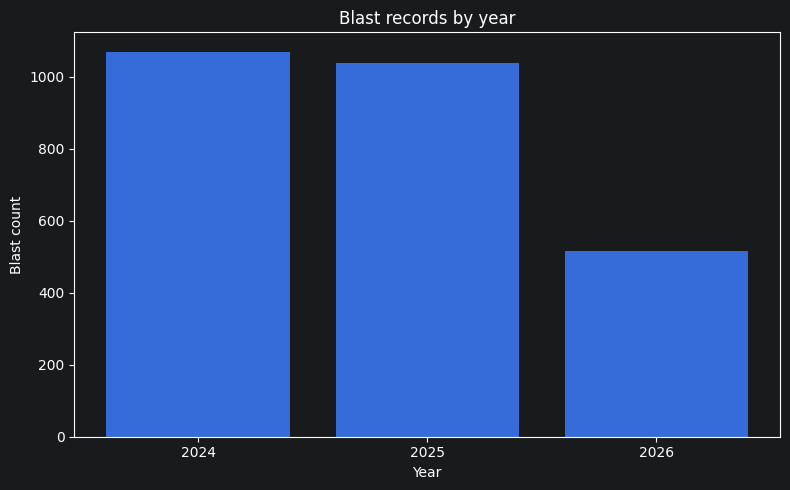

In [8]:
plt.figure(figsize=(8, 5))
plt.bar(annual_inventory["year"].astype(str), annual_inventory["blasts"])
plt.title("Blast records by year")
plt.xlabel("Year")
plt.ylabel("Blast count")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "01_blasts_by_year.png", dpi=170)
plt.show()

## 4. Target summaries and distributions

In [9]:
TARGETS = [
    "average_power_kw",
    "specific_energy_kwh_t",
    "peak_power_kw",
]
target_summary = df[TARGETS].describe().T
display(target_summary)
target_summary.to_csv(RESULTS_DIR / "target_summary.csv")

,count,mean,std,min,25%,50%,75%,max
average_power_kw,"2,625.0000","2,754.2836",362.9644,"1,582.2316","2,504.3215","2,753.3955","2,987.2451","4,257.8859"
specific_energy_kwh_t,"2,625.0000",1.0868,0.1092,0.7904,1.0129,1.0744,1.1477,1.9799
peak_power_kw,"2,625.0000","3,252.5494",452.7374,"1,680.1885","2,940.2372","3,242.9720","3,541.6317","5,183.3224"


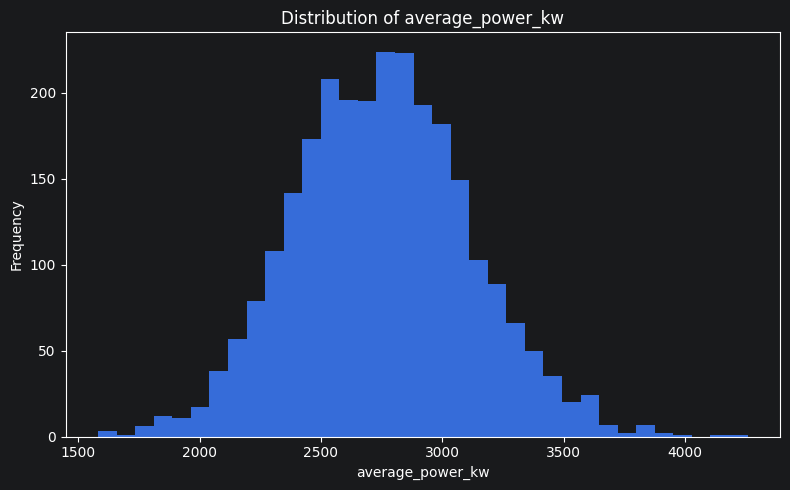

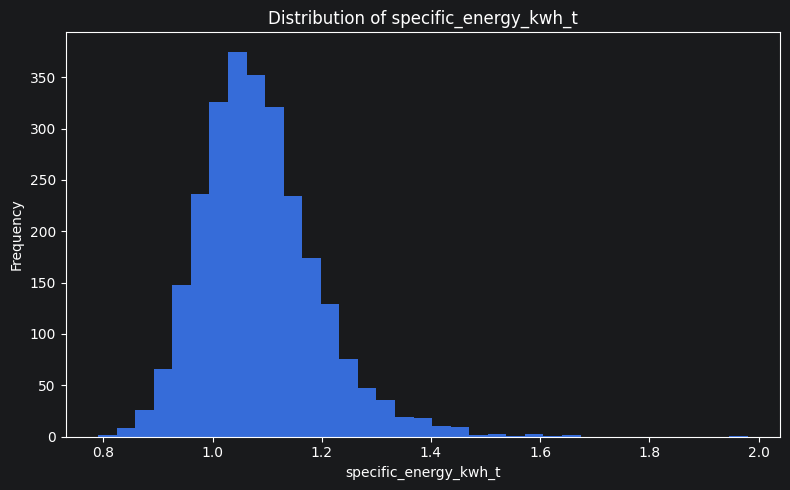

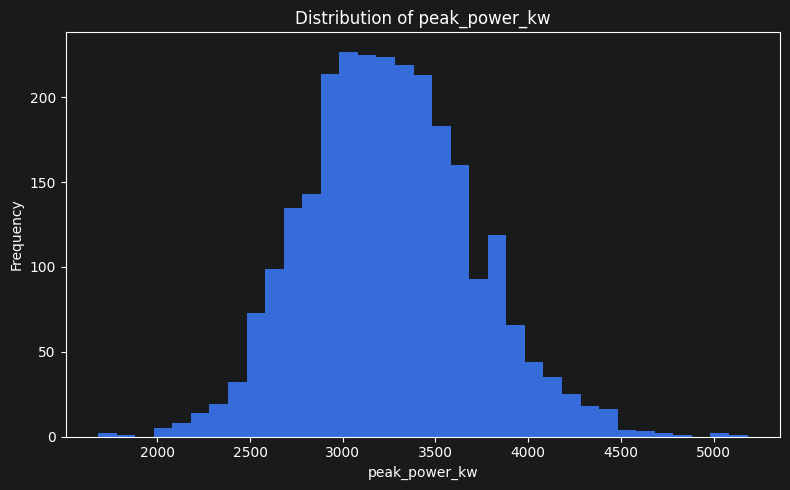

In [10]:
for target in TARGETS:
    plt.figure(figsize=(8, 5))
    plt.hist(df[target].dropna(), bins=35)
    plt.title(f"Distribution of {target}")
    plt.xlabel(target)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"02_distribution_{target}.png", dpi=170)
    plt.show()

## 5. Operational relationships

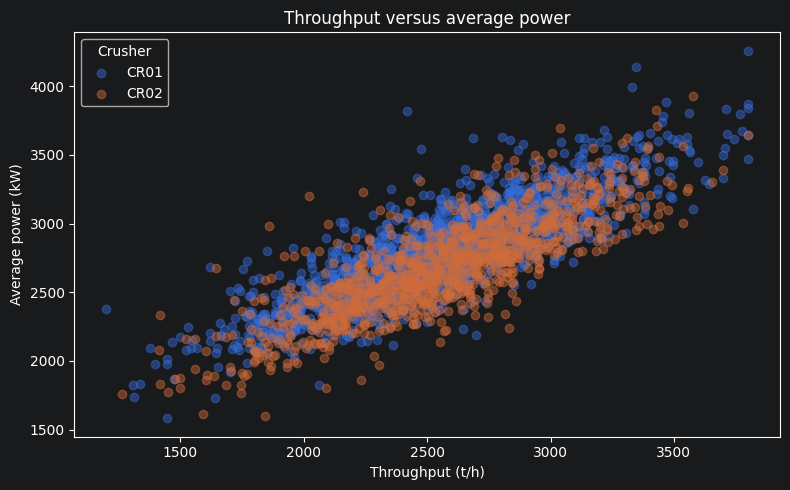

In [11]:
plt.figure(figsize=(8, 5))
for crusher, group in df.groupby("crusher_id"):
    plt.scatter(
        group["throughput_tph"],
        group["average_power_kw"],
        alpha=0.45,
        label=str(crusher),
    )
plt.title("Throughput versus average power")
plt.xlabel("Throughput (t/h)")
plt.ylabel("Average power (kW)")
plt.legend(title="Crusher")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "03_throughput_vs_average_power.png", dpi=170)
plt.show()

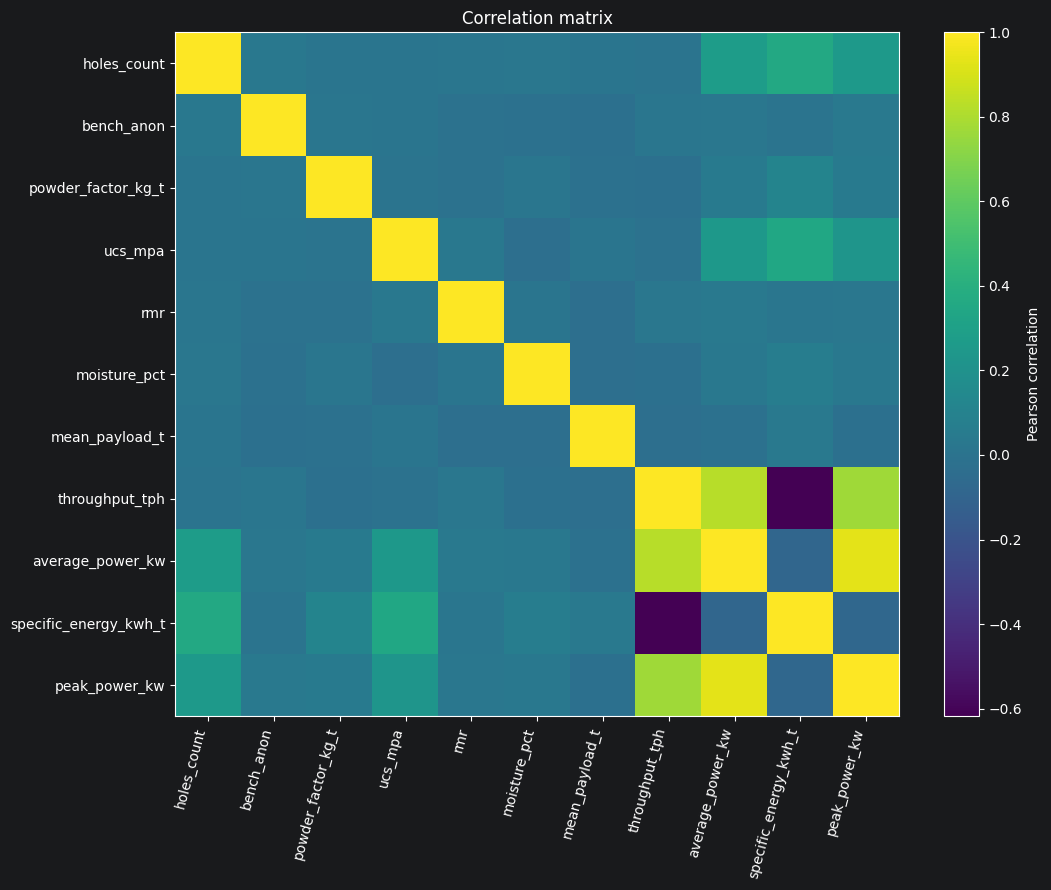

,holes_count,bench_anon,powder_factor_kg_t,ucs_mpa,rmr,moisture_pct,mean_payload_t,throughput_tph,average_power_kw,specific_energy_kwh_t,peak_power_kw
holes_count,1.0000,0.0320,0.0100,0.0100,0.0180,0.0260,0.0130,0.0040,0.2760,0.3580,0.2520
bench_anon,0.0320,1.0000,0.0160,0.0110,-0.0100,-0.0170,-0.0180,0.0150,0.0220,0.0030,0.0350
powder_factor_kg_t,0.0100,0.0160,1.0000,0.0020,-0.0060,0.0140,-0.0160,-0.0220,0.0500,0.1130,0.0460
ucs_mpa,0.0100,0.0110,0.0020,1.0000,0.0280,-0.0300,0.0090,-0.0100,0.2430,0.3480,0.2280
rmr,0.0180,-0.0100,-0.0060,0.0280,1.0000,0.0130,-0.0260,0.0210,0.0390,0.0170,0.0250
moisture_pct,0.0260,-0.0170,0.0140,-0.0300,0.0130,1.0000,-0.0290,-0.0200,0.0280,0.0700,0.0300
mean_payload_t,0.0130,-0.0180,-0.0160,0.0090,-0.0260,-0.0290,1.0000,-0.0280,-0.0180,0.0330,-0.0190
throughput_tph,0.0040,0.0150,-0.0220,-0.0100,0.0210,-0.0200,-0.0280,1.0000,0.8270,-0.6180,0.7710
average_power_kw,0.2760,0.0220,0.0500,0.2430,0.0390,0.0280,-0.0180,0.8270,1.0000,-0.0870,0.9340
specific_energy_kwh_t,0.3580,0.0030,0.1130,0.3480,0.0170,0.0700,0.0330,-0.6180,-0.0870,1.0000,-0.0780


In [12]:
numeric_columns = [
    "holes_count",
    "bench_anon",
    "powder_factor_kg_t",
    "ucs_mpa",
    "rmr",
    "moisture_pct",
    "mean_payload_t",
    "throughput_tph",
    "average_power_kw",
    "specific_energy_kwh_t",
    "peak_power_kw",
]
corr = df[numeric_columns].corr()

plt.figure(figsize=(11, 9))
image = plt.imshow(corr, aspect="auto")
plt.colorbar(image, label="Pearson correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=75, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation matrix")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "04_correlation_matrix.png", dpi=170)
plt.show()

display(corr.round(3))
corr.to_csv(RESULTS_DIR / "correlation_matrix.csv")

## 6. Export data-quality report

In [13]:
report = {
    "dataset_path": str(DATA_PATH),
    "rows": int(len(df)),
    "columns": int(df.shape[1]),
    "date_min": str(df["firing_datetime"].min()),
    "date_max": str(df["firing_datetime"].max()),
    "schema": schema_result,
    "duplicate_blasts": duplicate_blasts,
    "invalid_dates": invalid_dates,
    "nonpositive_throughput": nonpositive_throughput,
    "nonpositive_average_power": nonpositive_power,
    "data_status_counts": df["data_status"].value_counts(dropna=False).to_dict(),
}

with open(RESULTS_DIR / "data_quality_report.json", "w", encoding="utf-8") as file:
    json.dump(report, file, indent=2, ensure_ascii=False)

quality_summary.to_csv(RESULTS_DIR / "data_quality_by_column.csv", index=False)
audit_flags.to_csv(RESULTS_DIR / "data_quality_flags.csv", index=False)

print("EDA and validation completed.")
print("Artifacts saved in:", RESULTS_DIR)

EDA and validation completed.
Artifacts saved in: E:\Luis\Luis_Quispe_Metodos\research-methods-deliverables\05_pipeline\results
